In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

# First order statistics on connectivity matrix (whole)

[1 2 3 4]
[np.float64(-0.87), np.float64(1.64), np.float64(-1.66), np.float64(1.2)]
[np.float64(-1.05), np.float64(-1.85), np.float64(-0.12), np.float64(-2.0)]
[np.float64(1.43), np.float64(0.52), np.float64(-1.16), np.float64(-0.7)]
[np.float64(-0.82), np.float64(0.6), np.float64(0.08), np.float64(-0.36)]


,0,1,2,3
0,-0.87,1.64,-1.66,1.20
1,-1.05,-1.85,-0.12,-2.00
2,1.43,0.52,-1.16,-0.70
3,-0.82,0.60,0.08,-0.36


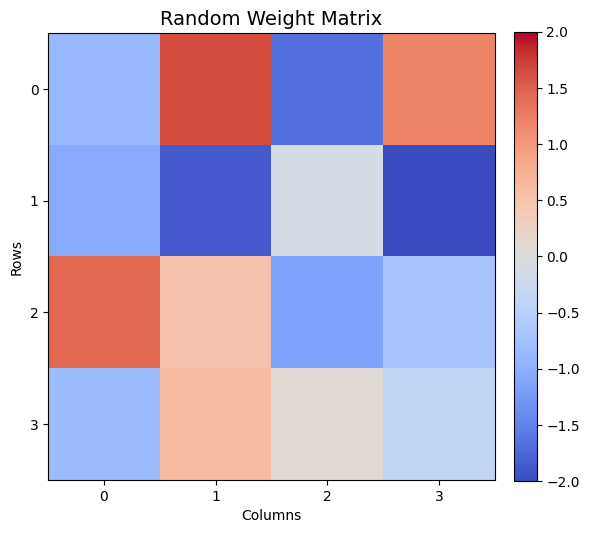

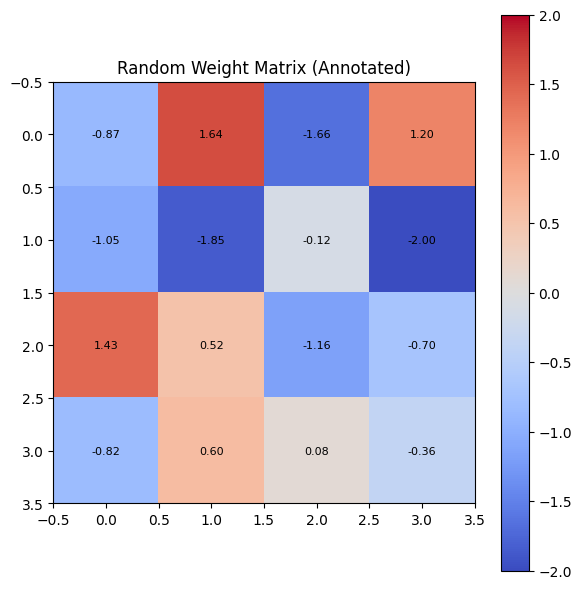

In [ ]:
## Illustration of matrix to powerpoint
import random
import numpy as np
import pandas as pd

rows = []
start, stop = 1, 5
ticks = np.arange(1, 5, 1)
print(ticks)
for i in range(start, stop):
    row = [(np.round(random.uniform(-2, 2), decimals=2)) for _ in range(start, stop)]
    rows.append(row)

for r in rows:
    print(r)

df = pd.DataFrame(rows)
display(df)

### Without entry values

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

im = plt.imshow(
    df.values,
    cmap="coolwarm",     # good for negative ↔ positive
    vmin=-2,
    vmax=2
)

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.title("Random Weight Matrix", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.xticks(range(df.shape[1]))
plt.yticks(range(df.shape[0]))

plt.tight_layout()
# plt.savefig("weight_matrix.png", dpi=300)
plt.show()


### With entry values

plt.figure(figsize=(6, 6))
im = plt.imshow(df.values, cmap="coolwarm", vmin=-2, vmax=2)
plt.colorbar(im)

for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        plt.text(
            j, i,
            f"{df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Random Weight Matrix (Annotated)")
plt.tight_layout()
# plt.savefig("weight_matrix_annotated.png", dpi=300)
plt.show()


# Formatting

In [38]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 18,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    # "figure.figsize": (16, 6)       # Figsize
    "figure.figsize": (8, 6)       # Figsize
})

In [2]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 18,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 18,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
})

In [3]:
## Reusable color utility
# I use this one
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


# File path handling

In [ ]:
import os

figure_folder = 'figures'


In [4]:
import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Create a simple DataFrame
# -----------------------------
data = {
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "score": [88.5, 92.0, 79.5],
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Define OneDrive path
# -----------------------------
# Example (Windows):
# Path(r"C:\Users\YourUsername\OneDrive\test_folder")
#
# Example (Mac):
# Path("/Users/YourUsername/OneDrive/test_folder")

# Onedrive base where evertything will be saved
ONEDRIVE_BASE = Path(r"C:\Users\Silje\OneDrive\Dokumenter\mscneuroscience20242026\nevr3901\simulations_folder")

# Optional: ensure the folder exists
ONEDRIVE_BASE.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3. Save DataFrame to CSV
# -----------------------------
# csv_path = ONEDRIVE_BASE / "new_test_dataframe.csv"
# df.to_csv(csv_path, index=False)

# print(f"CSV file successfully saved to:\n{csv_path}")




# Store values for plotting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)] 


########## Dataframe and dictionary ##########

rows = []  # Container for rows of dataframe
weights_dict = {}  # Dictionary for weight arrays

for dyn in dynamics:

    # Simulation number corresponding to dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_number:
            for seed in seed_number:
                # Loop through simulations of pqif across seeds


                # dataframe_title = f'{dyn}\simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}' # load dataframe

                dataframe_title = ONEDRIVE_BASE / f'simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}' # load dataframe

                simulation_id = f'{dyn}_{sim}_{pqif}_{seed}'  # Shared across dataframe and dictionary

                try:  # Notify if something did not exist
                    # weights_df = pd.read_csv(dataframe_title, header=None).values


                    # TODO: It is different values for these two
                    # weights_df = pd.read_csv(dataframe_title, header=None).values
                    weights_df = pd.read_csv(dataframe_title, header=None)  # Make dataframe, no header
                    weights_np = weights_df.to_numpy()  # Make numpy representation of dataframe (this is now recommended over the .values property)

                except FileNotFoundError:
                    print(f"File not found: {dataframe_title}, will be skipped.")
                    continue  # Go to next iteration


                # Flatten to 1D array
                # weights = weights_df.flatten()
                weights = weights_np.flatten()

                # Standard deviation and mean of weights for current seed of vrest/slope and pqif
                sd = np.std(weights)
                mean = np.mean(weights)

                if pqif == 1:
                    vr = None
                    f = slope_qif


                row = [simulation_id, dyn, sim, vr, f, pqif, seed, sd, mean]  # Store all data associated with the connectivity matrix + a simulationID to the weights in dictionary
                rows.append(row)  # Append row to what becomes the dataframe later

                # weights_dict[simulation_id] = weights  # Dictionary mapping simulationID to weight array FLATTENED VERSION
                weights_dict[simulation_id] = weights_df  # Dictionary mapping simulationID to weight array


########## Make dataframe ##########

columns = ['simulationID', 'dynamic', 'simulation', 'vrest', 'slope', 'pqif', 'seed', 'std', 'mean']
df = pd.DataFrame(rows, columns=columns)


########## Make a copy of dataframe for further use ##########

wDF = df.copy()

########## Print statements to control ##########
print(wDF.head())
print(wDF.tail())
# print(weights_dict)
# for i in weights_dict.items():
#     print(i)

wDF.to_csv("stats_connectivitymatrix.csv", index=False)

         simulationID       dynamic  simulation  vrest  slope  pqif  seed  \
0  oscillations_1_0_0  oscillations           1   -8.5  14.44   0.0     0   
1  oscillations_1_0_1  oscillations           1   -8.5  14.44   0.0     1   
2  oscillations_1_0_2  oscillations           1   -8.5  14.44   0.0     2   
3  oscillations_1_0_3  oscillations           1   -8.5  14.44   0.0     3   
4  oscillations_1_0_4  oscillations           1   -8.5  14.44   0.0     4   

        std      mean  
0  0.255446 -0.000068  
1  0.233008  0.000042  
2  0.233865 -0.000029  
3  0.239014 -0.000076  
4  0.234006 -0.000066  
           simulationID    dynamic  simulation  vrest  slope  pqif  seed  \
1995  sequences_12_1_45  sequences          12    NaN  10.74   1.0    45   
1996  sequences_12_1_46  sequences          12    NaN  10.74   1.0    46   
1997  sequences_12_1_47  sequences          12    NaN  10.74   1.0    47   
1998  sequences_12_1_48  sequences          12    NaN  10.74   1.0    48   
1999  sequenc

In [ ]:
# DF to CSV
# wDF = pd.read_csv('stats_connectivitymatrix.csv')
wDF = pd.read_csv('stats_connectivitymatrix.csv', index_col=0)  # if already saved CSV with index columns
display(wDF)

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean
0,oscillations_1_0_0,oscillations,1,-8.5,14.44,0.0,0,0.255446,-0.000068
1,oscillations_1_0_1,oscillations,1,-8.5,14.44,0.0,1,0.233008,0.000042
2,oscillations_1_0_2,oscillations,1,-8.5,14.44,0.0,2,0.233865,-0.000029
3,oscillations_1_0_3,oscillations,1,-8.5,14.44,0.0,3,0.239014,-0.000076
4,oscillations_1_0_4,oscillations,1,-8.5,14.44,0.0,4,0.234006,-0.000066
...,...,...,...,...,...,...,...,...,...
1995,sequences_12_1_45,sequences,12,NaN,10.74,1.0,45,0.213726,0.021462
1996,sequences_12_1_46,sequences,12,NaN,10.74,1.0,46,0.211047,0.021321
1997,sequences_12_1_47,sequences,12,NaN,10.74,1.0,47,0.218655,0.021589
1998,sequences_12_1_48,sequences,12,NaN,10.74,1.0,48,0.197260,0.021970


In [7]:
# pqif=1 have the same slope in each simulation and vrest=None

wDF_filtered1 = wDF[(wDF['seed'] == 1) & (wDF['pqif'] == 1)]

display(wDF_filtered1)

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean
201,oscillations_1_1_1,oscillations,1,NaN,10.74,1.0,1,0.291150,0.000089
451,oscillations_2_1_1,oscillations,2,NaN,10.74,1.0,1,0.292010,0.000769
701,oscillations_3_1_1,oscillations,3,NaN,10.74,1.0,1,0.291583,-0.000210
951,oscillations_4_1_1,oscillations,4,NaN,10.74,1.0,1,0.289360,-0.000472
1201,sequences_9_1_1,sequences,9,NaN,10.74,1.0,1,0.198957,0.022106
1451,sequences_10_1_1,sequences,10,NaN,10.74,1.0,1,0.209068,0.022123
1701,sequences_11_1_1,sequences,11,NaN,10.74,1.0,1,0.196895,0.022287
1951,sequences_12_1_1,sequences,12,NaN,10.74,1.0,1,0.209723,0.021447


In [10]:
neuron = 2
connectivity_matrix = (weights_dict['oscillations_1_0_10']).copy()

print(f"Strongest input neuron {neuron} receives: {connectivity_matrix.loc[neuron].max()}")  # Strongest input neuron i receives
print(f"Strongest output neuron {neuron} sends: {connectivity_matrix[neuron].max()}") # strongest output neuron 2 sends


print(f"Most influential neuron overall: {connectivity_matrix.sum(axis=0).idxmax()}")  # Most influential neuron overall
print(f"Total incoming synaptic strength to neuron i: {connectivity_matrix.sum(axis=1)}")  # Total incoming synaptic strength to neuron i
print(f"Most driven neuron: Neuron {connectivity_matrix.sum(axis=1).idxmax()}")  # Most driven neuron: I.e. find the row label where the value is maximal from incoming synaptic strength

print(f"==============================\nTop synapses: \ni, j, synaptic value\n{connectivity_matrix.stack().nlargest(4)}")  # Top synapses: Stack entries of W_ij, each element is a single synapse. nlargest shows the n largest

Strongest input neuron 2 receives: 1.932088140313921
Strongest output neuron 2 sends: 1.6542510992281183
Most influential neuron overall: 84
Total incoming synaptic strength to neuron i: 0      0.218487
1     -0.053716
2     -0.089490
3      0.007107
4      0.286432
         ...   
195   -0.378560
196   -0.150077
197    0.255193
198   -1.086336
199    0.895260
Length: 200, dtype: float64
Most driven neuron: Neuron 80
Top synapses: 
i, j, synaptic value
11   190    3.472179
24   179    2.945204
151  60     2.804015
5    84     2.779396
dtype: float64


# Motifs

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    for sim, vr, f in zip(simulation_number, vrest, slope):

        dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)

        # display(df_results)


        # sorted = df_results.sort_values(by=['pqif', 'seed'])

        # if sim == simulation_number[0]:
        #     display(sorted)

        # for pqif, name in zip(pqif_values, names):
        for pqif in pqif_values:

            # df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15) & (df_results['seed']==0)]
            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)] 


            # display(df_filtered)

# display(test_1)
# display(test_2)

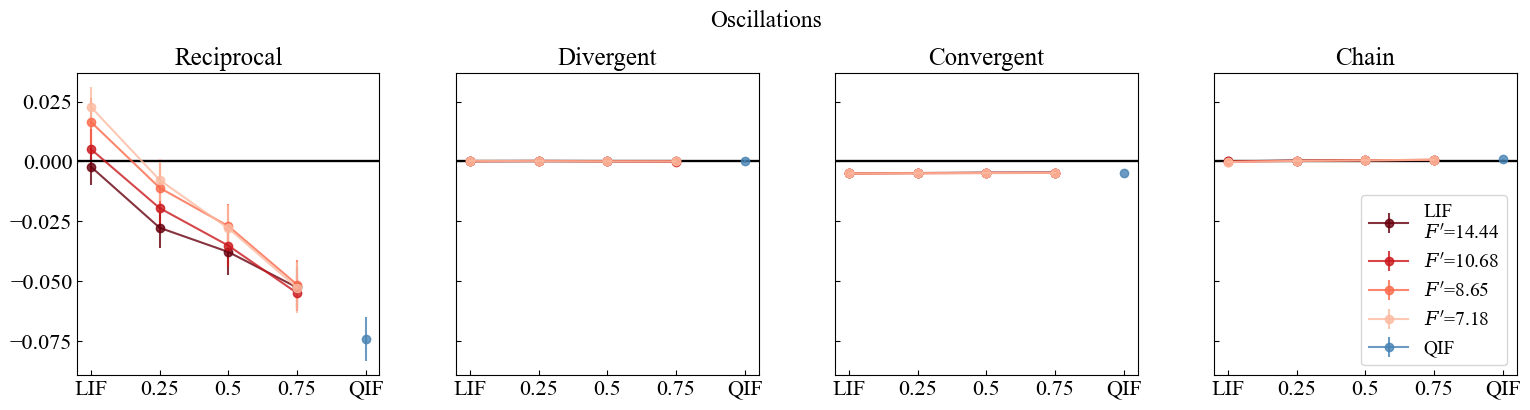

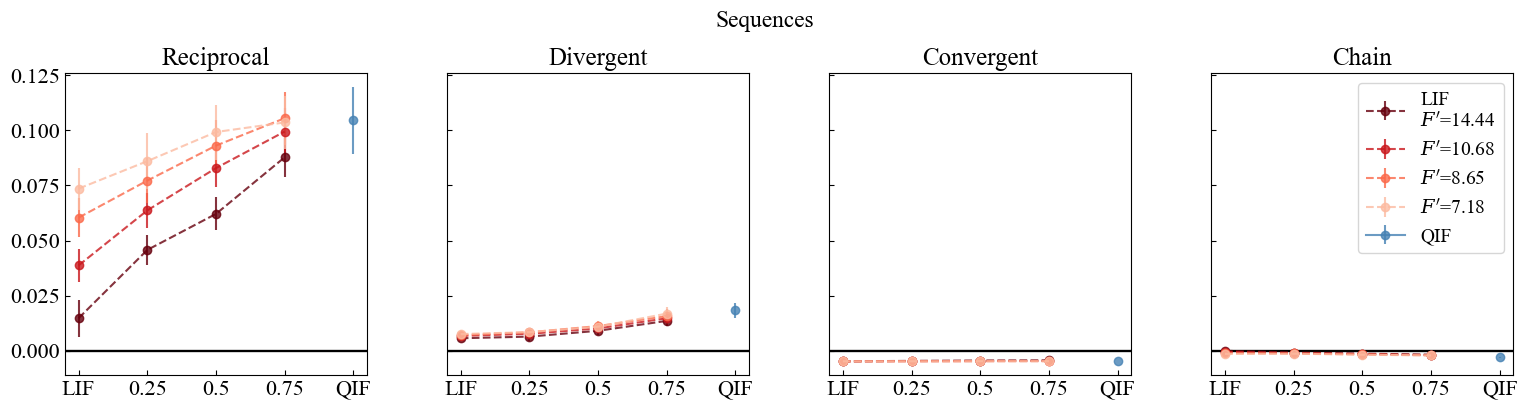

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
        linestyle = '-'
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
        linestyle = '--'
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        # dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        # display(df_results)


        # for pqif, name in zip(pqif_values, names):
        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            # df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15) & (df_results['seed']==0)]
            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds
            # display(stats)

            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        if sim == simulation_number[0]:
            label = f"LIF\n$F'$={f}"
        else:
            label= f"$F'$={f}"

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                label=label,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            # axs[i].set_ylim()
            
    # TODO collapse all QIF and plot alone

    # QIF separate
    # TODO decide on a specific simulation?
    df_qif = df_results[(df_results['pqif'] == 1) & (df_results['nloop'] == 15)]  # is now a dataframe for QIF, with 50 seeds TODO

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    # x_qif = [1]  # QIF
    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    
    if dyn == "oscillations":
        plt.legend(loc='lower right')
    elif dyn == "sequences":
        plt.legend(loc="upper right")
    plt.suptitle(f"{dyn.capitalize()}")
    plt.tight_layout()
    plt.show

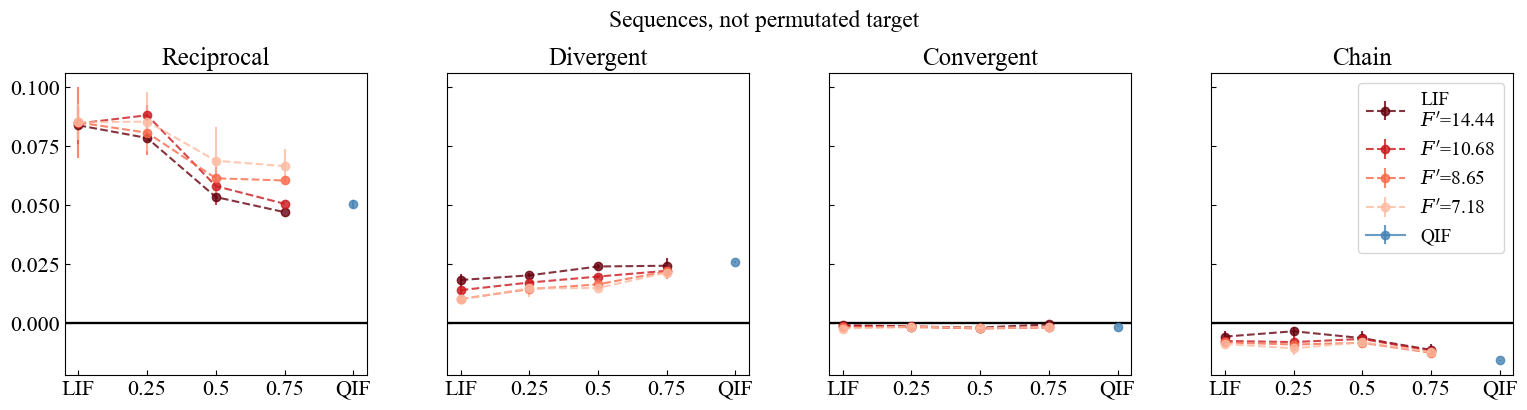

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = [ "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
        linestyle = '-'
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
        linestyle = '--'
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        # dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        dataframe_title = f"simulacion_{sim}\simulacion_{sim}_resultados.csv"

        df_results = pd.read_csv(dataframe_title)

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        # display(df_results)


        # for pqif, name in zip(pqif_values, names):
        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            # df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15) & (df_results['seed']==0)]
            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds
            # display(stats)

            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        if sim == simulation_number[0]:
            label = f"LIF\n$F'$={f}"
        else:
            label= f"$F'$={f}"

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                label=label,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            # axs[i].set_ylim()
            
    # TODO collapse all QIF and plot alone

    # QIF separate
    # TODO decide on a specific simulation?
    df_qif = df_results[(df_results['pqif'] == 1) & (df_results['nloop'] == 15)]  # is now a dataframe for QIF, with 50 seeds TODO

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    # x_qif = [1]  # QIF
    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    
    if dyn == "oscillations":
        plt.legend(loc='lower right')
    elif dyn == "sequences":
        plt.legend(loc="upper right")
    plt.suptitle(f"{dyn.capitalize()}, not permutated target")
    plt.tight_layout()
    plt.show

# Histogram of weight distribution for homogenous networks

## Permutated sequences

Used seed [30]


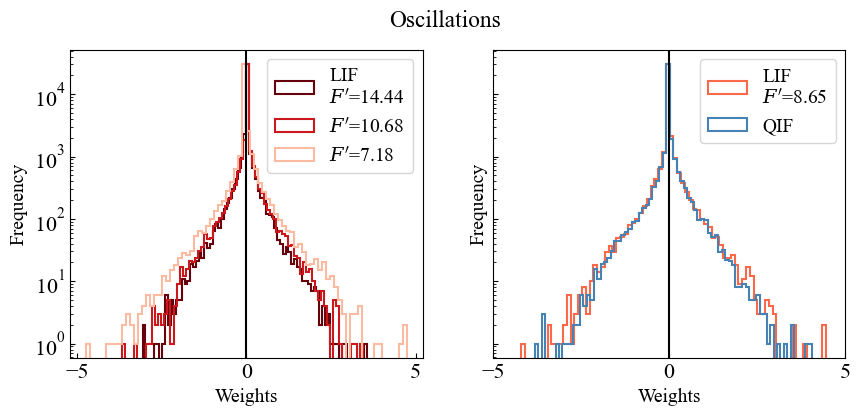

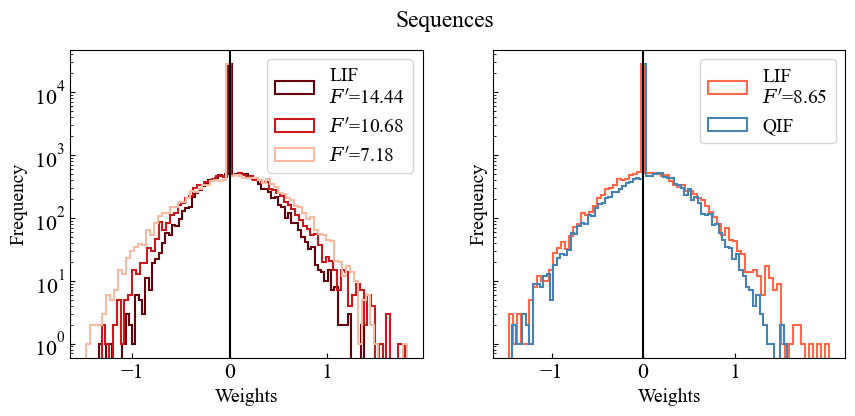

,dyn,permutated?,sim,f,pqif,std,mean
0,sequences,permutated,9,14.44,0,0.177793,0.015635
1,sequences,permutated,9,14.44,1,0.211368,0.021697
2,sequences,permutated,10,10.68,0,0.210808,0.017968
3,sequences,permutated,10,10.68,1,0.214247,0.021609
4,sequences,permutated,11,8.65,0,0.230201,0.020076
5,sequences,permutated,11,8.65,1,0.213843,0.022083
6,sequences,permutated,12,7.18,0,0.239582,0.021956
7,sequences,permutated,12,7.18,1,0.212500,0.021472


In [12]:
# ========== Histogram of weight distribution for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os
import random


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']

# seed_number = [i for i in range(0, 1)] # Only use one seed for this
seed_number = [random.randint(1, 49)]
print(f"Used seed {seed_number}")

rows = []

########## Figure loop ##########
for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    figname = f"{dyn}_histogram_weights_homogenous_networks.svg"

    #### Create figure and axes

    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2,
        figsize=(10,4),  # TODO review
        sharey=True
    )

    # fig, (ax1, ax2) = plt.subplots(
    #     figsize=(16, 10),
    #     nrows=1, ncols=2
    # )

    # ax_map = {
    #     'A': axes[0],
    #     'B': axes[1],
    # }

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_homogenous:
            for seed in seed_number:

                #### Take out values to plot

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata

                ID = df_filtered['simulationID'].item()  # Simulation ID

                current_weights_noflatten = weights_dict[ID].to_numpy()  # Weight array not flattened
                current_weights = current_weights_noflatten.flatten()

                std = current_weights.std()
                mn = current_weights.mean()

                if dyn == 'sequences':
                    rows.append([dyn, "permutated", sim, f, pqif, std, mn])



                #### Color formatting

                if pqif == 1:
                    colors = 'steelblue'
                else:
                    colors = color_map_vrest[vr]


                #### Figure control flow

                if pqif == 0 and f in [14.44, 10.68, 7.18]:  # Left

                    if sim == simulation_number[0]:  # LIF header in legend
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = f"$F'$={f}"

                    ax1.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1.5, histtype='step', label=label)
                    
                elif f == 8.65:  # Right
                    if pqif == 0:
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = 'QIF'

                    ax2.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1.5, histtype='step', label=label)

                else:  # Ignore others
                    continue


    #### Shared formatting
    plt.suptitle(f"{dyn.capitalize()}")

    if dyn == 'oscillations':
        tick_positions = [-5, 0, 5]
    elif dyn == 'sequences':
        tick_positions = [-1, 0, 1]

    for ax in (ax1, ax2):
        ax.legend(loc='upper right')
        ax.set_xlabel("Weights")
        ax.set_ylabel("Frequency")
        ax.axvline(0, color="black")
        ax.set_xticks(tick_positions)
    
    # full_path = os.path.join(figure_folder, figname)
    # plt.savefig(full_path, format="svg")

    plt.show()

cols = ["dyn", "permutated?", "sim", "f", "pqif", "std", "mean"]

stats_newversion = pd.DataFrame(rows, columns=cols)

display(stats_newversion)

## Not permutated sequences

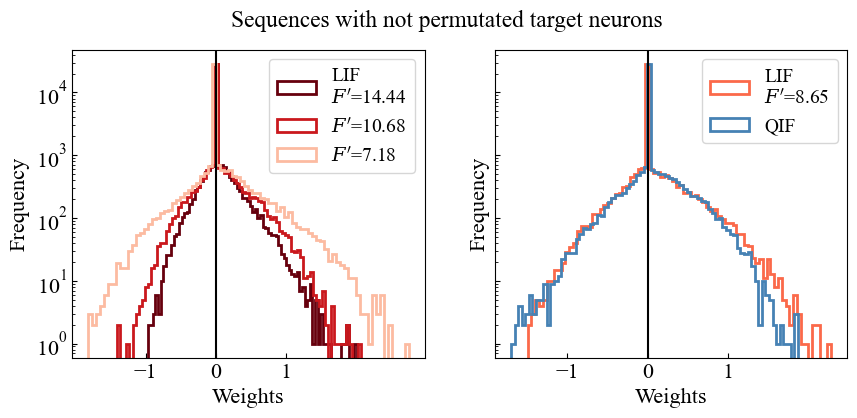

,dyn,permutated?,sim,f,pqif,std,mean
0,sequences,not permutated,9,14.44,0,0.175970,0.022690
1,sequences,not permutated,9,14.44,1,0.244782,0.030624
2,sequences,not permutated,10,10.68,0,0.218825,0.027784
3,sequences,not permutated,10,10.68,1,0.244782,0.030624
4,sequences,not permutated,11,8.65,0,0.262310,0.032221
5,sequences,not permutated,11,8.65,1,0.244782,0.030624
6,sequences,not permutated,12,7.18,0,0.314110,0.035597
7,sequences,not permutated,12,7.18,1,0.244782,0.030624


In [49]:
# ========== Histogram of weight distribution for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 1)] # Only use one seed for this

rows = []
########## Figure loop ##########
for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    figname = f"{dyn}_histogram_weights_homogenous_networks.svg"

    #### Create figure and axes

    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2,
        figsize=(10,4),  # TODO review
        sharey=True
    )

    # fig, (ax1, ax2) = plt.subplots(
    #     figsize=(16, 10),
    #     nrows=1, ncols=2
    # )

    # ax_map = {
    #     'A': axes[0],
    #     'B': axes[1],
    # }

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_homogenous:

            # dataframe_title = f"simulacion_{sim}/simulacion_{sim}_resultados.csv"
            # dataframe_title = f"simulacion_{sim}/simulacion_{sim}_corrientes/simulacion_{sim}_corrientes_pqif_{pqif}.csv"
            dataframe_title = f"simulacion_{sim}/simulacion_{sim}_matrices_pesos/simulacion_{sim}_pesos_pqif_{pqif}_matriz_iloop_11_semilla_0"
            weights = pd.read_csv(dataframe_title, header=None)


            weights_np = weights.to_numpy()
            weights_flattened = weights_np.flatten()

            #                 # Standard deviation and mean of weights for current seed of vrest/slope and pqif
            # sd = np.std(weights)
            # mean = np.mean(weights)

            std = weights_flattened.std()
            mn = weights_flattened.mean()

            rows.append([dyn, "not permutated", sim, f, pqif, std, mn])

            

            #### Take out values to plot

            # df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata

            # ID = df_filtered['simulationID'].item()  # Simulation ID

            # current_weights_noflatten = weights_dict[ID].to_numpy()  # Weight array not flattened
            # current_weights = current_weights_noflatten.flatten()



            #### Color formatting

            if pqif == 1:
                colors = 'steelblue'
            else:
                colors = color_map_vrest[vr]


            #### Figure control flow

            if pqif == 0 and f in [14.44, 10.68, 7.18]:  # Left

                if sim == simulation_number[0]:  # LIF header in legend
                    label = f"LIF\n$F'$={f}"
                else:
                    label = f"$F'$={f}"

                ax1.hist(weights_flattened, bins=80, log=True, color=colors, alpha=1, linewidth=2, histtype='step', label=label)
                
            elif f == 8.65:  # Right
                if pqif == 0:
                    label = f"LIF\n$F'$={f}"
                else:
                    label = 'QIF'

                ax2.hist(weights_flattened, bins=80, log=True, color=colors, alpha=1, linewidth=2, histtype='step', label=label)

            else:  # Ignore others
                continue


    #### Shared formatting
    plt.suptitle(f"{dyn.capitalize()} with not permutated target neurons")

    if dyn == 'oscillations':
        tick_positions = [-5, 0, 5]
    elif dyn == 'sequences':
        tick_positions = [-1, 0, 1]

    for ax in (ax1, ax2):
        ax.legend(loc='upper right')
        ax.set_xlabel("Weights")
        ax.set_ylabel("Frequency")
        ax.axvline(0, color="black")
        ax.set_xticks(tick_positions)
    
    # full_path = os.path.join(figure_folder, figname)
    # plt.savefig(full_path, format="svg")

    plt.show()

cols = ["dyn", "permutated?", "sim", "f", "pqif", "std", "mean"]

stats_oldversion = pd.DataFrame(rows, columns=cols)

display(stats_oldversion)

In [45]:
# display(stats_oldversion)

import pandas as pd
comparison_seq = pd.concat([stats_newversion, stats_oldversion], ignore_index=True)

# display(df)
comparison_seq = comparison_seq.sort_values(by=["mean", "std"])

display(comparison_seq)

,dyn,permutated?,sim,f,pqif,std,mean
0,sequences,permutated,9,14.44,0,0.184370,0.015330
2,sequences,permutated,10,10.68,0,0.209881,0.018001
4,sequences,permutated,11,8.65,0,0.242007,0.020319
3,sequences,permutated,10,10.68,1,0.199720,0.021600
7,sequences,permutated,12,7.18,1,0.210439,0.021668
6,sequences,permutated,12,7.18,0,0.243127,0.021891
1,sequences,permutated,9,14.44,1,0.201246,0.022051
5,sequences,permutated,11,8.65,1,0.196266,0.022291
8,sequences,not permutated,9,14.44,0,0.175970,0.022690
10,sequences,not permutated,10,10.68,0,0.218825,0.027784


# Std+Mean vs. F' homogenous networks

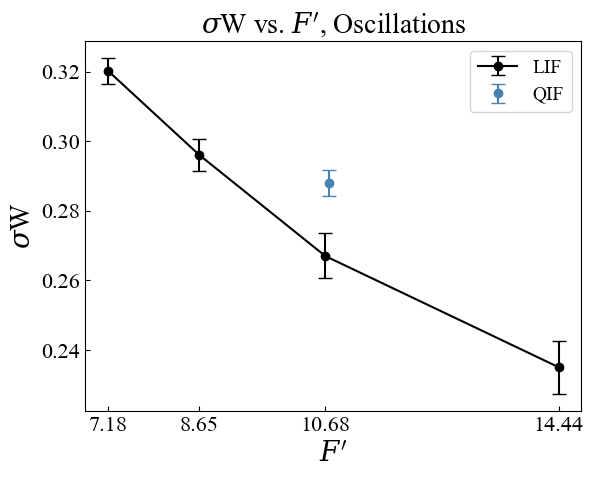

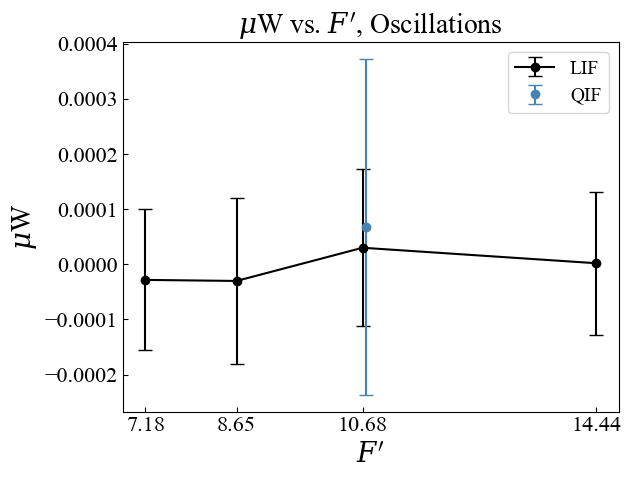

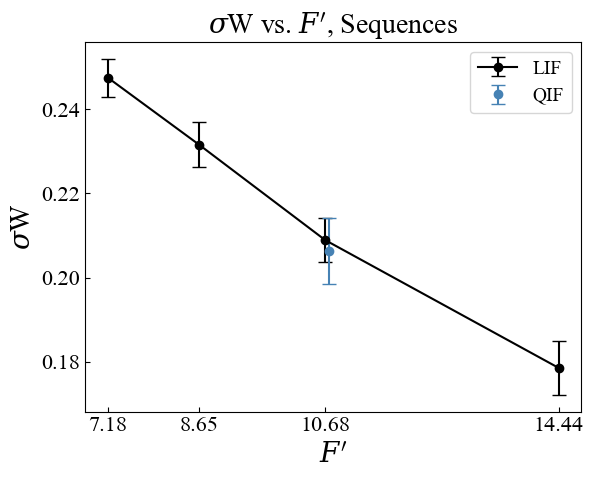

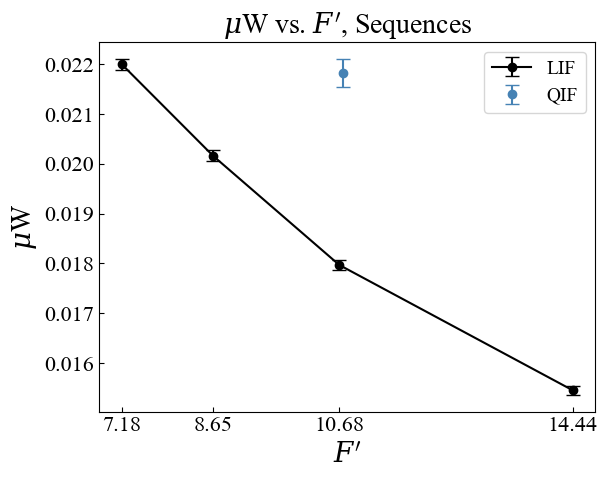

In [56]:
# ========== Standard deviation or Mean of weights vs. slope for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

columns = ['std', 'mean']

x_ticks = [14.44, 10.68, 8.65, 7.18]

########## Figure loop ##########

for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()


    #### Plot same figures for both STD and mean
    for c in columns:

        # figname = f"{dyn}_{c}_vs_slope_homogenous_networks.svg"
        fig, ax = plt.subplots()


        for pqif in pqif_homogenous:

            y = []
            yerr = []
            x = slope


            for sim, vr, f in zip(simulation_number, vrest, slope):

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()

                if pqif == 0: # For LIF: Make list across slope
                    y.append(y_i)
                    yerr.append(yerr_i)

                elif pqif == 1:  # Only one value for QIF since it is the same in each simulation
                    y = y_i
                    yerr = yerr_i

            colors = color_map_pqif[pqif]

            #### Title and labels depending on if STD or mean 

            if c == 'std':
                title = f"$\sigma$W vs. $F'$, {dyn.capitalize()}"
                xlabel = f"$F'$"
                ylabel = f"$\sigma$W"

            elif c == "mean":
                title = f"$\mu$W vs. $F'$, {dyn.capitalize()}"
                xlabel = f"$F'$"
                ylabel = f"$\mu$W"

            #### Plot values on ax

            if pqif == 0:
                label = 'LIF'
                ax.errorbar(x, y, yerr, fmt='o-', capsize=5, color=colors, label=label)

            elif pqif == 1:
                label = 'QIF'
                ax.errorbar(slope_qif, y, yerr, fmt='o', capsize=5, color=colors, label=label)

        ax.set_title(title)
        ax.set_xticks(x_ticks)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        # if c == "mean":
        #     ax.set_ylim(0, 0.024)
        plt.legend()
        # full_path = os.path.join(figure_folder, figname)
        # plt.savefig(full_path, format="svg")
        plt.show()



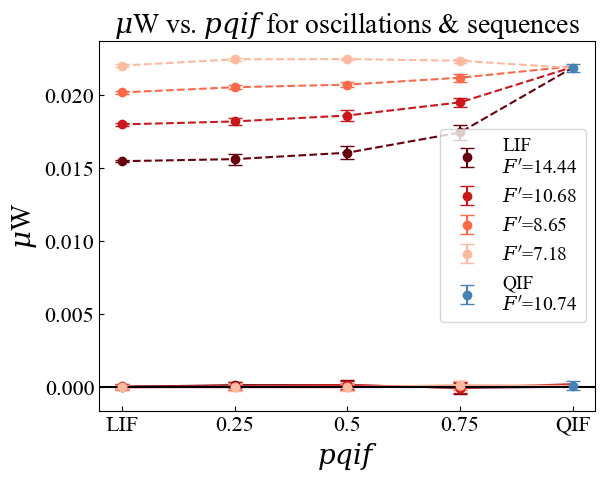

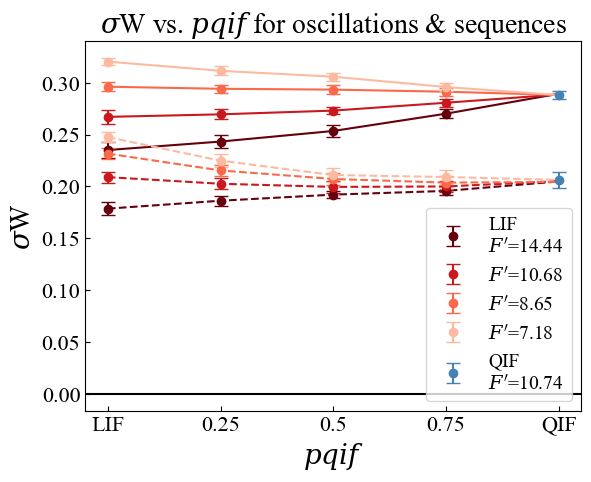

In [66]:
# ========== Mean of weights vs. pqif for heterogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

# columns = ['mean']
columns = ['mean', 'std']

x_ticks = ['LIF', 0.25, 0.5, 0.75, 'QIF']

########## Figure loop ##########

#### Plot same figures for both STD and mean
for c in columns:

    fig, ax = plt.subplots()  # Both dynamics should be in the same figure for this one
    # figname = f"both_mean_vs_pqif.svg"

    for dyn in dynamics:

        #### Correct simulaton numbers from dynamics

        if dyn == 'oscillations':
            simulation_number = [i for i in range(1,5)]
        elif dyn == 'sequences':
            simulation_number = [i for i in range(9, 13)]
        else:
            print('Invalid dynamics')
            sys.exit()


        for sim, vr, f in zip(simulation_number, vrest, slope):

            y = []
            yerr = []
            x = pqif_number

            for pqif in pqif_number:


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()


                y.append(y_i)
                yerr.append(yerr_i)


            if (sim == simulation_number[0]):
                label = f"LIF\n$F'$={f}"
            else:
                label = f"$F'$={f}"

            if dyn == 'sequences':
                label = None


            ########## For formatting purposes, I plot double to allow connecting lines to QIF without having errorbars on top of eachother for QIF specifically ##########

            no_qif_x = x[:-1]
            no_qif_y = y[:-1]
            no_qif_yerr = yerr[:-1]

            if dyn == 'oscillations':
                linestyle='-'
            elif dyn == 'sequences':
                linestyle = '--'

            # ax.errorbar(x, y, yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)
            ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)
            ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], label=None)

        
        ########## Title and tick labels ##########
        if c == 'std':
            title = f"$\sigma$W vs. $pqif$ for oscillations & sequences"
            xlabel = f"$pqif$"
            ylabel = f"$\sigma$W"

        elif c == "mean":
            title = f"$\mu$W vs. $pqif$ for oscillations & sequences"
            xlabel = f"$pqif$"
            ylabel = f"$\mu$W"


        ########## Add QIF ##########
        df_filtered_qif = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == 1)]

        y_qif = df_filtered_qif[c].mean()  # y
        yerr_qif = df_filtered_qif[c].std()  # y-error
        x_qif = 1  # x

        if dyn == 'oscillations': # first
            label = f"QIF\n$F'$={slope_qif}"
        else:
            label = None


        ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, color='steelblue', label=label)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xticks(pqif_number, x_ticks)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='black')


    plt.legend()
    # full_path = os.path.join(figure_folder, figname)
    # plt.savefig(full_path, format="svg")
    plt.show()
